

This notebook implements the full Assignment 1 pipeline required by the course handbook:
EDA -> split -> preprocessing -> Dataset/DataLoader -> five mandatory model families
(Linear/Softmax, MLP, CNN, LSTM/GRU, Transformer) trained and compared under one
shared data split and evaluation protocol, followed by error analysis.

- **Debug dataset:** MNIST (not used for reported results).
- **Main comparison dataset:** Fashion-MNIST (all reported numbers below).
- **Optional extension dataset:** CIFAR-10 (not run here — see Section 11.2 of the handbook).

> Fill in every `TODO` before submission. Cells that print `[TODO: discuss ...]` need a short
> written analysis added by the group after the cell has actually been run.


### Pipeline overview (Section 3.2 of the handbook)

```
Raw Fashion-MNIST (28x28 uint8)
      -> preprocessing (Normalize; train split also gets RandomHorizontalFlip + RandomCrop)
      -> ArrayImageDataset / DataLoader (identical for all 5 models)
      -> model (Linear | MLP | CNN | GRU | Transformer -- each reshapes the same batch internally)
      -> CrossEntropyLoss (no softmax applied before the loss)
      -> Adam optimizer + ReduceLROnPlateau scheduler
      -> prediction (argmax over logits)
      -> post-processing (none needed for classification)
      -> evaluation (accuracy, macro-F1, confusion matrix, qualitative examples)
```


In [1]:
# Environment (run once). Uncomment if the packages are not already installed.
!pip install torch torchvision scikit-learn matplotlib pandas


In [2]:
import os, time, copy, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from tqdm.auto import tqdm  # progress-bar tracking for training / evaluation loops

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## 0.1 Mount Google Drive and set up output folders

Every figure, trained-model checkpoint, and result table produced by this notebook is written
to `OUTPUT_DIR` on Google Drive (in addition to being shown inline), so nothing is lost if the
Colab runtime disconnects or is reset. Re-running this cell is safe — folders are created only
if they don't already exist.

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = "/content/drive/MyDrive/CO3133_Assignments"
except ImportError:
    print("Not running on Colab — using a local output folder instead of Google Drive.")
    DRIVE_ROOT = "."

OUTPUT_DIR = os.path.join(DRIVE_ROOT, "A1_Foundations_FashionMNIST")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
CKPT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")

for d in (FIG_DIR, CKPT_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)

print("Saving all outputs under:", OUTPUT_DIR)


Mounted at /content/drive
Saving all outputs under: /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST


In [4]:
# Auto-captured reproducibility info (Section 3.2 / 4.2 of the handbook) --
# reused verbatim in the Reproducibility section at the end, instead of being typed by hand.
import platform

env_info = {
    "seed": SEED,
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "device": str(DEVICE),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A (CPU run)",
    "platform": platform.platform(),
}
for k, v in env_info.items():
    print(f"{k}: {v}")


seed: 42
python_version: 3.13.15
torch_version: 2.11.0+cu128
torchvision_version: 0.26.0+cu128
device: cuda
gpu_name: Tesla T4
platform: Linux-6.6.122+-x86_64-with-glibc2.39


## 1. Data loading

MNIST is downloaded only to show it is available for early debugging (Section 10, handbook).
All reported results in this notebook use Fashion-MNIST.


In [5]:
mnist_debug_train = torchvision.datasets.MNIST(root="./data", train=True, download=True)
print("MNIST debug set (not reported):", len(mnist_debug_train), "images")

# Main dataset for the assignment
fmnist_train_raw = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True)
fmnist_test_raw = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True)

train_images_all = fmnist_train_raw.data.numpy()      # (60000, 28, 28) uint8
train_labels_all = fmnist_train_raw.targets.numpy()   # (60000,)
test_images = fmnist_test_raw.data.numpy()            # (10000, 28, 28) uint8
test_labels = fmnist_test_raw.targets.numpy()         # (10000,)

print("Fashion-MNIST train+val pool:", train_images_all.shape, train_labels_all.shape)
print("Fashion-MNIST official test :", test_images.shape, test_labels.shape)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.7MB/s]


MNIST debug set (not reported): 60000 images


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.8MB/s]

Fashion-MNIST train+val pool: (60000, 28, 28) (60000,)
Fashion-MNIST official test : (10000, 28, 28) (10000,)


## 2. Exploratory Data Analysis (EDA)

Required for this assignment (Section 13 of the handbook): class distribution, input size,
imbalance analysis, representative samples.


Detected 10 classes from the training data.
   class_id   class_name  train_count  train_pct
0         0  T-shirt/top         6000       10.0
1         1      Trouser         6000       10.0
2         2     Pullover         6000       10.0
3         3        Dress         6000       10.0
4         4         Coat         6000       10.0
5         5       Sandal         6000       10.0
6         6        Shirt         6000       10.0
7         7      Sneaker         6000       10.0
8         8          Bag         6000       10.0
9         9   Ankle boot         6000       10.0

Max/min class count ratio (imbalance ratio): 1.0


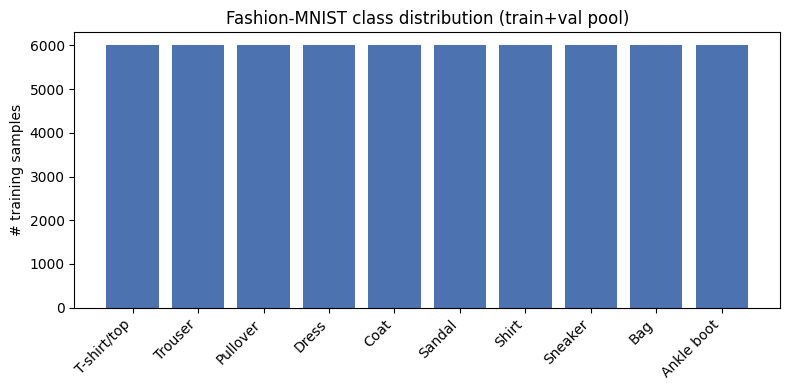

Input size: 28x28 grayscale (1 channel), pixel range [0, 255] as uint8.


In [6]:
# Discover class metadata from the loaded dataset during EDA
class_ids, counts = np.unique(train_labels_all, return_counts=True)
CLASS_NAMES = list(fmnist_train_raw.classes)
NUM_CLASSES = len(class_ids)

if len(CLASS_NAMES) != NUM_CLASSES:
    raise ValueError("Dataset class names do not match the labels found in the training data.")

print(f"Detected {NUM_CLASSES} classes from the training data.")

# Class distribution (imbalance analysis)
dist_df = pd.DataFrame({
    "class_id": class_ids,
    "class_name": CLASS_NAMES,
    "train_count": counts,
})
dist_df["train_pct"] = 100 * dist_df["train_count"] / dist_df["train_count"].sum()
print(dist_df)
print("\nMax/min class count ratio (imbalance ratio):",
      dist_df['train_count'].max() / dist_df['train_count'].min())

plt.figure(figsize=(8, 4))
plt.bar(dist_df["class_name"], dist_df["train_count"], color="#4C72B0")
plt.xticks(rotation=45, ha="right")
plt.ylabel("# training samples")
plt.title("Fashion-MNIST class distribution (train+val pool)")
plt.tight_layout()
plt.show()

print("Input size: 28x28 grayscale (1 channel), pixel range [0, 255] as uint8.")


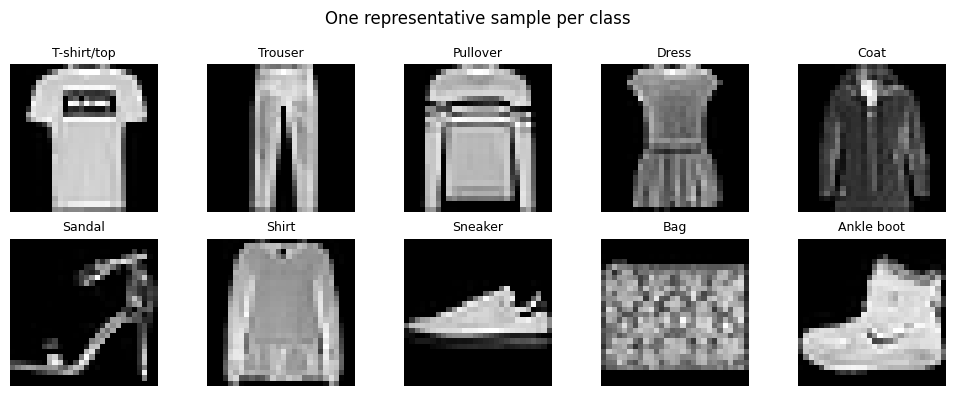

Computed pixel mean = 0.2860, pixel std = 0.3530 (used for Normalize())


In [7]:
# Representative samples: one example per class
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for c in range(NUM_CLASSES):
    idx = np.where(train_labels_all == c)[0][0]
    ax = axes[c // 5, c % 5]
    ax.imshow(train_images_all[idx], cmap="gray")
    ax.set_title(CLASS_NAMES[c], fontsize=9)
    ax.axis("off")
plt.suptitle("One representative sample per class")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_eda_representative_samples.png"), dpi=150, bbox_inches="tight")
plt.show()

# Pixel statistics used later for normalization
pixel_mean = (train_images_all / 255.0).mean()
pixel_std = (train_images_all / 255.0).std()
print(f"Computed pixel mean = {pixel_mean:.4f}, pixel std = {pixel_std:.4f} (used for Normalize())")


**[TODO: discuss]** Is the class distribution balanced? Does the imbalance ratio
computed above justify (or not justify) using macro-F1 in addition to accuracy?


## 3. Train / validation / test split

- Official Fashion-MNIST **test** split (10,000 images) is held out untouched and used only for
  final reporting.
- The official **train** pool (60,000 images) is further split into **train** (48,000 — 80%) and
  **val** (12,000 — 20%) with a *stratified* split so every class keeps the same proportion in both
  subsets, using a fixed seed for reproducibility.
- All five models below are trained/evaluated on exactly the same split (fairness constraint,
  Section 12.2 of the handbook).


In [8]:
train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_all)),
    test_size=0.2,  # 80/20 train/val split (48,000 train / 12,000 val)
    stratify=train_labels_all,
    random_state=SEED,
)

train_images, train_labels = train_images_all[train_idx], train_labels_all[train_idx]
val_images, val_labels = train_images_all[val_idx], train_labels_all[val_idx]

print(f"train: {train_images.shape[0]} | val: {val_images.shape[0]} | test: {test_images.shape[0]}")
print("Split seed:", SEED, "| Stratified by label: yes | Split unit: one image = one sample")


train: 48000 | val: 12000 | test: 10000
Split seed: 42 | Stratified by label: yes | Split unit: one image = one sample


## 4. Preprocessing, Dataset and DataLoader

The same `Dataset`/`DataLoader` pipeline feeds all five models — each model reshapes the
flat `(N, 1, 28, 28)` batch internally (flatten, sequence-of-rows, or patches), so the
preprocessing stays identical across models (fairness constraint).

Data augmentation (`RandomHorizontalFlip`, `RandomRotation`, `RandomCrop`, `ColorJitter`) is applied to the
training split only; validation/test use only normalization.


In [9]:
# ==============================================================================
# 4. Custom Dataset & Data Transformations
# ==============================================================================

class ArrayImageDataset(Dataset):
    """
    Dataset nhận mảng NumPy thô và áp dụng transform cho từng mẫu.
    - Input images: ndarray uint8, shape (N, 28, 28) với giá trị [0, 255]
    - Input labels: ndarray int64, shape (N,) với giá trị nhãn [0, 9]
    """
    def __init__(self, images, labels, transform):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        # Trả về tổng số lượng mẫu N
        return len(self.images)

    def __getitem__(self, idx):
        # [Bước 1]: Lấy 1 mẫu ảnh và nhãn tại chỉ số idx
        #   - self.images[idx] có shape: (28, 28), dtype: uint8 (ảnh xám 2D)
        #   - self.labels[idx] có shape: () (số nguyên vô hướng / scalar)
        img = Image.fromarray(self.images[idx]).convert("L")
        label = int(self.labels[idx])                       # int scalar: 0 -> 9

        # [Bước 2]: Đi qua chuỗi transform (xem chi tiết kích thước từng bước bên dưới)
        #   - img sau transform: Tensor shape (1, 28, 28), dtype: torch.float32
        return self.transform(img), label


# ------------------------------------------------------------------------------
# Pipeline biến đổi dữ liệu cho tập TRAIN (có Data Augmentation)
# ------------------------------------------------------------------------------
train_transform = transforms.Compose([
    # Input ban đầu: PIL Image, kích thước (28 x 28), 1 channel (mode 'L')

    # Bước 1: Lật ngang ngẫu nhiên với xác suất 50% (giữ tính đối xứng vật lý tự nhiên)
    # -> Dimension: PIL Image vẫn giữ nguyên kích thước (28 x 28)
    transforms.RandomHorizontalFlip(p=0.5),

    # Bước 2: Xoay nhẹ góc ảnh ngẫu nhiên trong khoảng [-10, 10] độ (giả lập góc chụp nghiêng)
    # -> Dimension: PIL Image kích thước (28 x 28)
    transforms.RandomRotation(degrees=10),

    # Bước 3: Thêm padding 2 viền (thành 32x32) rồi crop ngẫu nhiên về lại (28x28)
    # -> Dimension: PIL Image kích thước (28 x 28)
    transforms.RandomCrop(28, padding=2),

    # Bước 4: Thay đổi ngẫu nhiên cường độ sáng và độ tương phản (+/- 20%)
    # -> Dimension: PIL Image kích thước (28 x 28)
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    # Bước 5: Chuyển PIL Image -> PyTorch Tensor, đồng thời scale pixel từ [0, 255] về [0.0, 1.0]
    # Thêm chiều kênh (channel dimension) ở đầu: (H, W) -> (C, H, W)
    # -> Dimension: torch.FloatTensor shape (1, 28, 28), dtype: torch.float32
    transforms.ToTensor(),

    # Bước 6: Chuẩn hóa Z-score: output = (input - pixel_mean) / pixel_std
    # Giúp dữ liệu có mean ~ 0 và std ~ 1 để gradient ổn định
    # -> Dimension: torch.FloatTensor shape (1, 28, 28) (kích thước không đổi)
    transforms.Normalize((pixel_mean,), (pixel_std,)),
])

# ------------------------------------------------------------------------------
# Pipeline biến đổi dữ liệu cho tập EVALUATION (Val & Test - KHÔNG dùng Augmentation)
# ------------------------------------------------------------------------------
eval_transform = transforms.Compose([
    # Input ban đầu: PIL Image, kích thước (28 x 28)

    # Bước 1: Chuyển PIL Image -> Tensor và scale [0.0, 1.0]
    # -> Dimension: torch.FloatTensor shape (1, 28, 28)
    transforms.ToTensor(),

    # Bước 2: Chuẩn hóa theo cùng mean/std của tập train
    # -> Dimension: torch.FloatTensor shape (1, 28, 28)
    transforms.Normalize((pixel_mean,), (pixel_std,)),
])

# ------------------------------------------------------------------------------
# Khởi tạo Dataset & DataLoader
# ------------------------------------------------------------------------------
BATCH_SIZE = 512

# Khởi tạo các Dataset (Train: 48.000 mẫu | Val: 12.000 mẫu | Test: 10.000 mẫu)
train_ds = ArrayImageDataset(train_images, train_labels, train_transform)
val_ds = ArrayImageDataset(val_images, val_labels, eval_transform)
test_ds = ArrayImageDataset(test_images, test_labels, eval_transform)

# DataLoader thực hiện batching (gom nhóm) các mẫu đơn lẻ thành các mini-batch:
# - train_loader: batch_size = 128 (có shuffle ngẫu nhiên)
# - val_loader & test_loader: batch_size = 256 (không shuffle)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)

# [Kiểm tra kích thước đầu ra từ DataLoader]:
# Gom B mẫu (1, 28, 28) -> Tensor (B, 1, 28, 28) với B = BATCH_SIZE = 128
# Gom B nhãn scalar     -> Tensor (B,) gồm 128 số nguyên nhãn [0 -> 9]
xb, yb = next(iter(train_loader))
print("One preprocessed batch image shape:", xb.shape, "| dtype:", xb.dtype)   # torch.Size([128, 1, 28, 28])
print("One preprocessed batch label shape:", yb.shape, "| dtype:", yb.dtype)   # torch.Size([128])


One preprocessed batch image shape: torch.Size([512, 1, 28, 28]) | dtype: torch.float32
One preprocessed batch label shape: torch.Size([512]) | dtype: torch.int64


## 5. Shared training / evaluation utilities

One generic training loop, evaluation function, and metric set is reused for every model so
that all five architectures are trained and compared under an identical protocol.


In [10]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def compute_class_metrics(y_true, y_pred, class_names=CLASS_NAMES):
    """
    Tính toán chi tiết Accuracy, Precision, Recall, F1 cho từng lớp riêng biệt,
    sau đó tổng hợp thành hàng Macro Average ở dòng cuối cùng.
    """
    prec_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)

    rows = []
    for c in range(len(class_names)):
        acc_c = ((y_pred == c) == (y_true == c)).mean()  # One-vs-Rest accuracy cho từng lớp
        support_c = (y_true == c).sum()
        rows.append({
            "Class ID": c,
            "Class Name": class_names[c],
            "Accuracy": round(float(acc_c), 4),
            "Precision": round(float(prec_per_class[c]), 4),
            "Recall": round(float(rec_per_class[c]), 4),
            "F1-Score": round(float(f1_per_class[c]), 4),
            "Support": int(support_c),
        })

    df = pd.DataFrame(rows)

    # Dòng tổng hợp Macro Average
    macro_row = pd.DataFrame([{
        "Class ID": "-",
        "Class Name": "Macro Average",
        "Accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "Precision": round(float(prec_per_class.mean()), 4),
        "Recall": round(float(rec_per_class.mean()), 4),
        "F1-Score": round(float(f1_per_class.mean()), 4),
        "Support": int(len(y_true)),
    }])

    return pd.concat([df, macro_row], ignore_index=True)


def fit(model, dataloader, criterion, optimizer, device=DEVICE):
    """Huấn luyện mô hình trong một epoch."""
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        all_preds.append(outputs.argmax(dim=1).detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    epoch_loss = running_loss / len(dataloader.dataset)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return epoch_loss, acc, prec, rec, macro_f1, y_true, y_pred


@torch.no_grad()
def evaluate(model, dataloader, criterion, device=DEVICE):
    """Đánh giá mô hình trên tập validation hoặc test."""
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        all_preds.append(outputs.argmax(dim=1).detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    epoch_loss = running_loss / len(dataloader.dataset)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return epoch_loss, acc, prec, rec, macro_f1, y_true, y_pred


def run_one_epoch(model, train_loader, val_loader, criterion, optimizer, device=DEVICE):
    """Chạy lần lượt fit() cho train và evaluate() cho validation trong một epoch."""
    train_loss, train_acc, train_prec, train_rec, train_f1, _, _ = fit(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
    return (train_loss, train_acc, train_prec, train_rec, train_f1,
            val_loss, val_acc, val_prec, val_rec, val_f1)


def run_epoch(model, loader, criterion, optimizer=None, desc=None):
    """Hàm wrapper hỗ trợ tương thích với các cell test/eval khác trong notebook."""
    if optimizer is not None:
        return fit(model, loader, criterion, optimizer, DEVICE)
    else:
        return evaluate(model, loader, criterion, DEVICE)


def train_model(model, name, epochs=15, lr=1e-3, patience=3):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()  # softmax is NOT applied before this loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

    history = {
        "train_loss": [], "train_acc": [], "train_prec": [], "train_rec": [], "train_f1": [],
        "val_loss": [], "val_acc": [], "val_prec": [], "val_rec": [], "val_f1": []
    }
    best_val_loss, best_state, bad_epochs = float("inf"), None, 0

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_prec, train_rec, train_f1, val_loss, val_acc, val_prec, val_rec, val_f1 = run_one_epoch(
            model, train_loader, val_loader, criterion, optimizer, DEVICE
        )
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_prec"].append(train_prec)
        history["train_rec"].append(train_rec)
        history["train_f1"].append(train_f1)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_prec"].append(val_prec)
        history["val_rec"].append(val_rec)
        history["val_f1"].append(val_f1)

        print(f"[{name}] Epoch {epoch:02d}/{epochs:02d} | "
              f"Train Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - Prec: {train_prec:.4f} - Rec: {train_rec:.4f} - F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f} - Acc: {val_acc:.4f} - Prec: {val_prec:.4f} - Rec: {val_rec:.4f} - F1: {val_f1:.4f}")

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"[{name}] early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
                break

    train_time = time.time() - t0
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, train_time


def measure_inference_time(model, loader, n_warmup_batches=2):
    model.eval()
    device_sync = torch.cuda.synchronize if DEVICE.type == "cuda" else (lambda: None)

    with torch.no_grad():
        for i, (xb, _) in enumerate(loader):
            if i >= n_warmup_batches:
                break
            _ = model(xb.to(DEVICE))

    device_sync()
    t0 = time.time()
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            _ = model(xb)
    device_sync()
    total_time = time.time() - t0
    return 1000 * total_time / len(loader.dataset)


## 6. Model 1 — Linear / Softmax classifier

A single linear layer on the flattened pixels. `CrossEntropyLoss` already combines
`log_softmax` + NLL, so softmax must **not** be applied inside the model.


In [11]:
class LinearClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, input_dim=28 * 28):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc(x)  # raw logits, no softmax


## 7. Model 2 — Multilayer Perceptron (MLP)

Flattened pixels through two hidden layers with ReLU activations and dropout regularization.


In [12]:
class MLP(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, input_dim=28 * 28, hidden_dims=(512, 256, 128), dropout=0.3):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(inplace=True), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


## 8. Model 3 — Convolutional Neural Network (CNN)

A small custom architecture (not a pretrained backbone, per Section 11.1 of the handbook):
three conv blocks (Conv -> BatchNorm -> ReLU, with two max-pools) that build up spatial
feature maps, followed by global average pooling and a linear classifier head.


In [13]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),   # 28->14
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),  # 14->7
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),                 # 7x7 feature maps
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


## 9. Model 4 — GRU (row-sequence model)

Each 28x28 image is treated as a sequence of **28 timesteps**, one per image row, where each
timestep is a 28-dimensional input vector (the pixel values of that row). A bidirectional GRU
processes the sequence and the final hidden representation is passed to a linear classifier.


In [14]:
# class RowSequenceGRU(nn.Module):
#     def __init__(self, num_classes=NUM_CLASSES, input_size=28, hidden_size=128, num_layers=1):
#         super().__init__()
#         self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
#                            batch_first=True, bidirectional=True)
#         out_dim = hidden_size * 2
#         self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(out_dim, num_classes))

#     def forward(self, x):
#         # x: (N, 1, 28, 28) -> sequence of 28 rows, each row is a 28-dim timestep input
#         x = x.squeeze(1)               # (N, seq_len=28, input_size=28)
#         out, _ = self.gru(x)           # out: (N, seq_len, hidden_size*2)
#         last = out[:, -1, :]           # representation after the last timestep
#         return self.classifier(last)


## 10. Model 5 — Transformer (patch-based)

Each image is split into non-overlapping 4x4 patches (49 patches of 16 pixels each), linearly
projected to `d_model`, prepended with a learnable `[CLS]` token, and given learnable
positional encodings before a standard `TransformerEncoder`. The `[CLS]` output feeds the
classifier head (a ViT-style design, adapted to a small grayscale image).


In [15]:
# class PatchTransformer(nn.Module):
#     def __init__(self, num_classes=NUM_CLASSES, img_size=28, patch_size=4, d_model=64,
#                  nhead=4, num_layers=3, dim_feedforward=128, dropout=0.1):
#         super().__init__()
#         assert img_size % patch_size == 0
#         self.patch_size = patch_size
#         num_patches = (img_size // patch_size) ** 2
#         patch_dim = patch_size * patch_size  # single channel

#         self.patch_embed = nn.Linear(patch_dim, d_model)
#         self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
#         self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))
#         nn.init.trunc_normal_(self.pos_embed, std=0.02)

#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
#             dropout=dropout, batch_first=True)
#         self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
#         self.norm = nn.LayerNorm(d_model)
#         self.classifier = nn.Linear(d_model, num_classes)

#     def forward(self, x):
#         N, p = x.size(0), self.patch_size
#         patches = x.unfold(2, p, p).unfold(3, p, p)              # (N,1,H/p,W/p,p,p)
#         patches = patches.contiguous().view(N, -1, p * p)         # (N, num_patches, patch_dim)
#         tokens = self.patch_embed(patches)                        # (N, num_patches, d_model) -- token/attention input
#         cls = self.cls_token.expand(N, -1, -1)
#         tokens = torch.cat([cls, tokens], dim=1) + self.pos_embed  # (N, num_patches+1, d_model)
#         out = self.encoder(tokens)                                 # attention output, same shape
#         out = self.norm(out[:, 0])                                 # take the [CLS] token representation
#         return self.classifier(out)


## 11. Train all five models under the same protocol

Same optimizer family (Adam), same scheduler policy, same number of epochs / early-stopping
patience, same data split and same batch size for every model (fairness constraints,
Section 12.2). Model-specific hyperparameters (hidden size, depth) are documented in each
model's constructor above.


In [16]:
MODEL_BUILDERS = {
    "Linear": lambda: LinearClassifier(),
    "MLP": lambda: MLP(),
    "CNN": lambda: SimpleCNN(),
    # "GRU": lambda: RowSequenceGRU(),
    # "Transformer": lambda: PatchTransformer(),
}

EPOCHS = 20
LR = 1e-4
PATIENCE = 3
N_SEEDS = 1  # increase to e.g. 3 to report mean +/- std over multiple runs when compute allows
             # (Section 3.3: "mean +/- standard deviation over multiple runs when feasible")


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


trained_models = {}   # keeps the first-seed model/history per architecture for the qualitative
histories = {}        # sections below (confusion matrix, correct/incorrect examples, ...)
summary_rows = []

for name, builder in MODEL_BUILDERS.items():
    print("=" * 70)
    print("Training:", name)
    seed_metrics = []
    for run_idx, seed in enumerate(range(SEED, SEED + N_SEEDS)):
        set_seed(seed)
        model = builder()
        n_params = count_params(model)
        model, history, train_time = train_model(
            model, f"{name}(seed={seed})", epochs=EPOCHS, lr=LR, patience=PATIENCE)

        criterion = nn.CrossEntropyLoss()
        test_loss, test_acc, test_prec, test_rec, test_f1, y_true, y_pred = run_epoch(model, test_loader, criterion, optimizer=None,
                                                                             desc=f"[{name}] test")
        inference_ms = measure_inference_time(model, test_loader)
        seed_metrics.append({"seed": seed, "test_accuracy": test_acc, "test_precision": test_prec, "test_recall": test_rec, "test_macro_f1": test_f1,
                              "train_time_sec": train_time, "inference_ms_per_sample": inference_ms,
                              "epochs_run": len(history["train_loss"])})

        # Tính bảng chi tiết từng class và Macro tổng thể
        class_metrics_df = compute_class_metrics(y_true, y_pred, CLASS_NAMES)
        print(f"\n--- Per-class metrics for {name} (seed={seed}) ---")
        print(class_metrics_df.to_string(index=False))

        if run_idx == 0:
            trained_models[name] = {
                "model": model, "y_true": y_true, "y_pred": y_pred,
                "class_metrics": class_metrics_df
            }
            histories[name] = history
            ckpt_path = os.path.join(CKPT_DIR, f"{name}.pt")
            torch.save({"state_dict": model.state_dict(), "seed": seed, "params": n_params,
                        "class_names": CLASS_NAMES, "model_name": name}, ckpt_path)
            print(f"Saved checkpoint -> {ckpt_path}")

    seed_df = pd.DataFrame(seed_metrics)
    summary_rows.append({
        "model": name,
        "params": n_params,
        "train_time_sec": round(seed_df["train_time_sec"].mean(), 1),
        "test_accuracy_mean": round(seed_df["test_accuracy"].mean(), 4),
        "test_accuracy_std": round(seed_df["test_accuracy"].std(ddof=0), 4) if N_SEEDS > 1 else 0.0,
        "test_precision_mean": round(seed_df["test_precision"].mean(), 4),
        "test_precision_std": round(seed_df["test_precision"].std(ddof=0), 4) if N_SEEDS > 1 else 0.0,
        "test_recall_mean": round(seed_df["test_recall"].mean(), 4),
        "test_recall_std": round(seed_df["test_recall"].std(ddof=0), 4) if N_SEEDS > 1 else 0.0,
        "test_macro_f1_mean": round(seed_df["test_macro_f1"].mean(), 4),
        "test_macro_f1_std": round(seed_df["test_macro_f1"].std(ddof=0), 4) if N_SEEDS > 1 else 0.0,
        "inference_ms_per_sample": round(seed_df["inference_ms_per_sample"].mean(), 4),
        "epochs_run": int(round(seed_df["epochs_run"].mean())),
        "n_seeds": N_SEEDS,
    })

results_df = pd.DataFrame(summary_rows).sort_values("test_accuracy_mean", ascending=False).reset_index(drop=True)
results_df


Training: Linear
[Linear(seed=42)] Epoch 01/20 | Train Loss: 1.7842 - Acc: 0.3812 - F1: 0.3760 | Val Loss: 1.2865 - Acc: 0.5857 - F1: 0.5678
[Linear(seed=42)] Epoch 02/20 | Train Loss: 1.3274 - Acc: 0.5553 - F1: 0.5445 | Val Loss: 1.0455 - Acc: 0.6560 - F1: 0.6448
[Linear(seed=42)] Epoch 03/20 | Train Loss: 1.1815 - Acc: 0.6037 - F1: 0.5946 | Val Loss: 0.9469 - Acc: 0.6842 - F1: 0.6783
[Linear(seed=42)] Epoch 04/20 | Train Loss: 1.0998 - Acc: 0.6246 - F1: 0.6173 | Val Loss: 0.8895 - Acc: 0.6986 - F1: 0.6924
[Linear(seed=42)] Epoch 05/20 | Train Loss: 1.0501 - Acc: 0.6418 - F1: 0.6357 | Val Loss: 0.8554 - Acc: 0.7090 - F1: 0.7026
[Linear(seed=42)] Epoch 06/20 | Train Loss: 1.0182 - Acc: 0.6492 - F1: 0.6431 | Val Loss: 0.8347 - Acc: 0.7113 - F1: 0.7053
[Linear(seed=42)] Epoch 07/20 | Train Loss: 0.9894 - Acc: 0.6581 - F1: 0.6524 | Val Loss: 0.8199 - Acc: 0.7140 - F1: 0.7086
[Linear(seed=42)] Epoch 08/20 | Train Loss: 0.9755 - Acc: 0.6620 - F1: 0.6564 | Val Loss: 0.8027 - Acc: 0.7235 - F1

,model,params,train_time_sec,test_accuracy_mean,test_accuracy_std,test_macro_f1_mean,test_macro_f1_std,inference_ms_per_sample,epochs_run,n_seeds
0,MLP,567434,518.4,0.8123,0.0,0.8043,0.0,0.1543,20,1
1,CNN,94410,550.8,0.8059,0.0,0.7983,0.0,0.1765,20,1
2,Linear,7850,530.0,0.7334,0.0,0.7274,0.0,0.1519,20,1


### 11.1 Evaluate-only path (reload a saved checkpoint, no retraining)

Demonstrates that the checkpoints saved in `CKPT_DIR` are sufficient to reproduce the
reported test metrics without retraining — this is what `evaluate.md` / the README's
"evaluate" command should run.


In [17]:
def load_and_evaluate(name):
    ckpt = torch.load(os.path.join(CKPT_DIR, f"{name}.pt"), map_location=DEVICE)
    model = MODEL_BUILDERS[name]().to(DEVICE)
    model.load_state_dict(ckpt["state_dict"])
    criterion = nn.CrossEntropyLoss()
    _, acc, prec, rec, f1, y_true, y_pred = run_epoch(model, test_loader, criterion, optimizer=None, desc=f"reload-eval {name}")
    print(f"[Reloaded {name}, seed={ckpt['seed']}] Overall Accuracy={acc:.4f} | Macro-F1={f1:.4f}")
    class_df = compute_class_metrics(y_true, y_pred, CLASS_NAMES)
    print("\n" + class_df.to_string(index=False))
    return model, class_df

_ = load_and_evaluate(results_df.iloc[0]["model"])  # sanity check on the top-ranked model


[reloaded MLP, seed=42] test_accuracy=0.8123 test_macro_f1=0.8043


## 12. Quantitative comparison

Accuracy alone is not treated as a sufficient basis for declaring a winner (Section 1.5 of the
handbook) — macro-F1, parameter count, training time and inference time are compared together.


 model  params  train_time_sec  test_accuracy_mean  test_accuracy_std  test_macro_f1_mean  test_macro_f1_std  inference_ms_per_sample  epochs_run  n_seeds
   MLP  567434           518.4              0.8123                0.0              0.8043                0.0                   0.1543          20        1
   CNN   94410           550.8              0.8059                0.0              0.7983                0.0                   0.1765          20        1
Linear    7850           530.0              0.7334                0.0              0.7274                0.0                   0.1519          20        1

N_SEEDS=1: single run per model. Set N_SEEDS>1 in Section 11 to report mean +/- std.


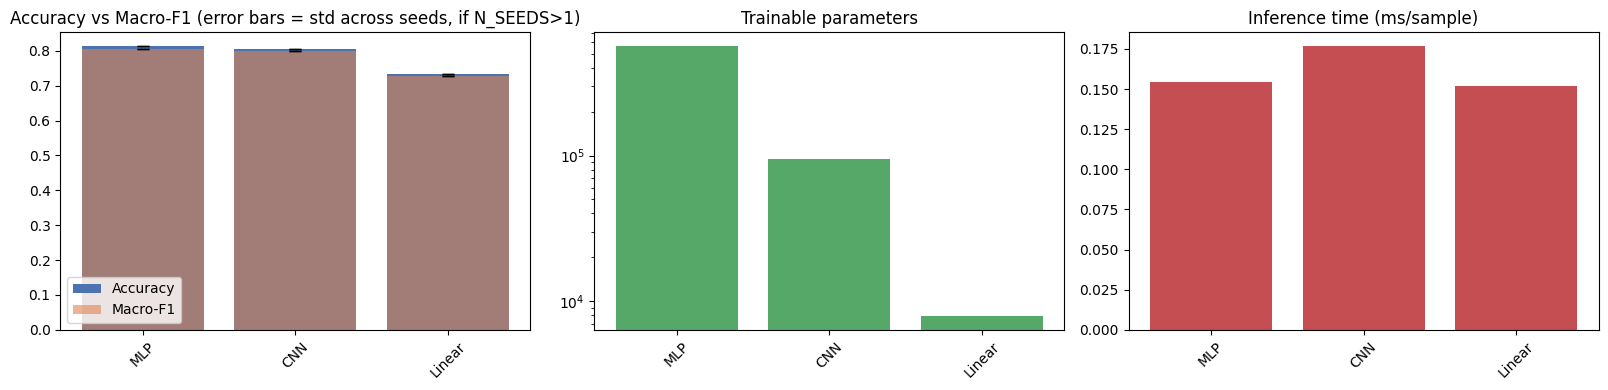

In [18]:
print(results_df.to_string(index=False))
if N_SEEDS > 1:
    print(f"\nMetrics above are mean +/- std over {N_SEEDS} seeds "
          f"({list(range(SEED, SEED + N_SEEDS))}).")
else:
    print("\nN_SEEDS=1: single run per model. Set N_SEEDS>1 in Section 11 to report mean +/- std.")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
x = np.arange(len(results_df))
width = 0.2

axes[0].bar(x - 1.5 * width, results_df["test_accuracy_mean"], width, label="Accuracy", color="#4C72B0")
axes[0].bar(x - 0.5 * width, results_df["test_precision_mean"], width, label="Precision", color="#55A868")
axes[0].bar(x + 0.5 * width, results_df["test_recall_mean"], width, label="Recall", color="#C44E52")
axes[0].bar(x + 1.5 * width, results_df["test_macro_f1_mean"], width, label="Macro-F1", color="#DD8452")
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df["model"], rotation=45, ha="right")
axes[0].set_title("Test Metrics: Accuracy, Precision, Recall, Macro-F1")
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)

axes[1].bar(results_df["model"], results_df["params"], color="#55A868")
axes[1].set_title("Trainable parameters")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(results_df["model"], results_df["inference_ms_per_sample"], color="#C44E52")
axes[2].set_title("Inference time (ms/sample)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "12_model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()


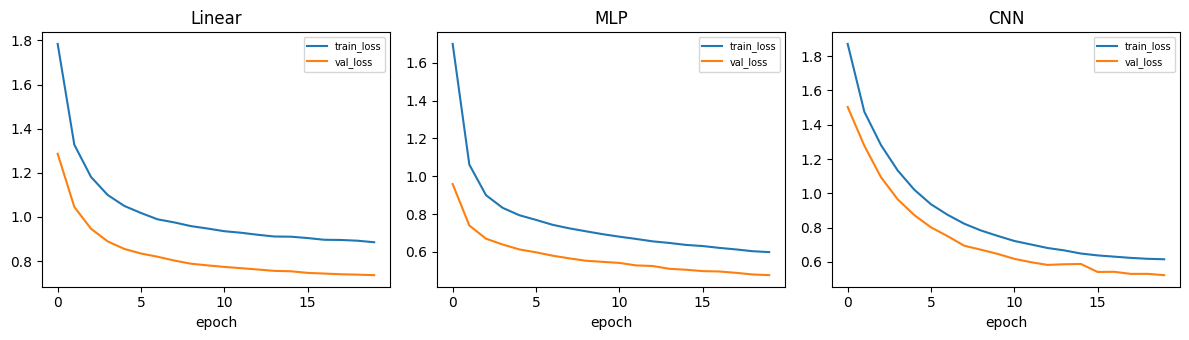

In [19]:
# Training / validation curves for every model
fig, axes = plt.subplots(1, len(histories), figsize=(4 * len(histories), 3.5), sharey=False)
for ax, (name, h) in zip(axes, histories.items()):
    ax.plot(h["train_loss"], label="train_loss")
    ax.plot(h["val_loss"], label="val_loss")
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "12_training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()


## 13. Confusion matrices


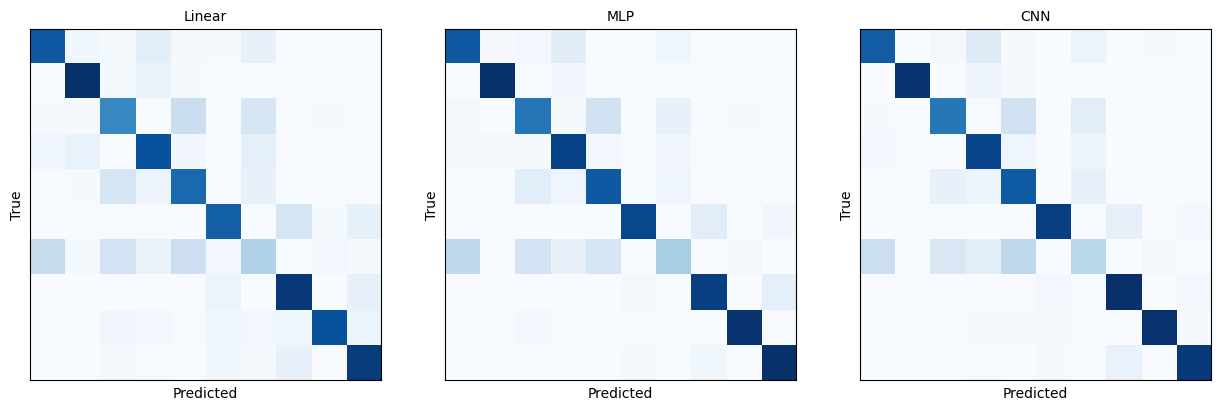

In [20]:
fig, axes = plt.subplots(1, len(trained_models), figsize=(4.2 * len(trained_models), 4))
for ax, (name, d) in zip(axes, trained_models.items()):
    cm = confusion_matrix(d["y_true"], d["y_pred"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticks([])
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticks([])
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "13_confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()


## 14. Qualitative results — correct and incorrect predictions

For the best model (by test macro-F1), a grid of correctly and incorrectly classified test
images is shown below, with true vs predicted labels.


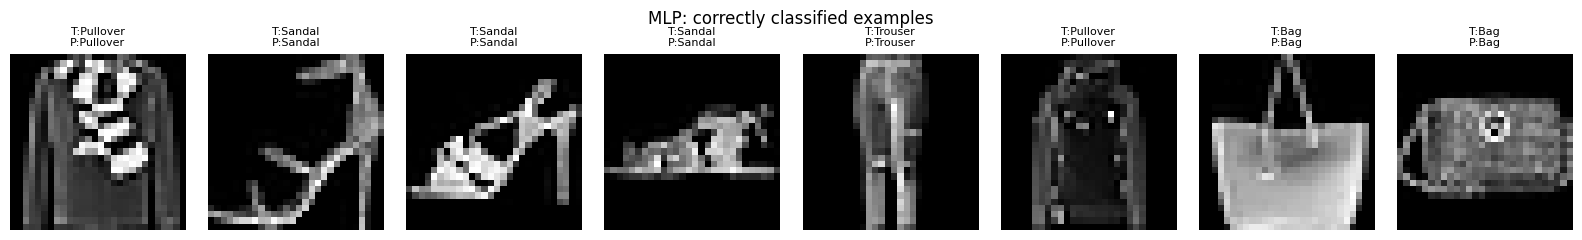

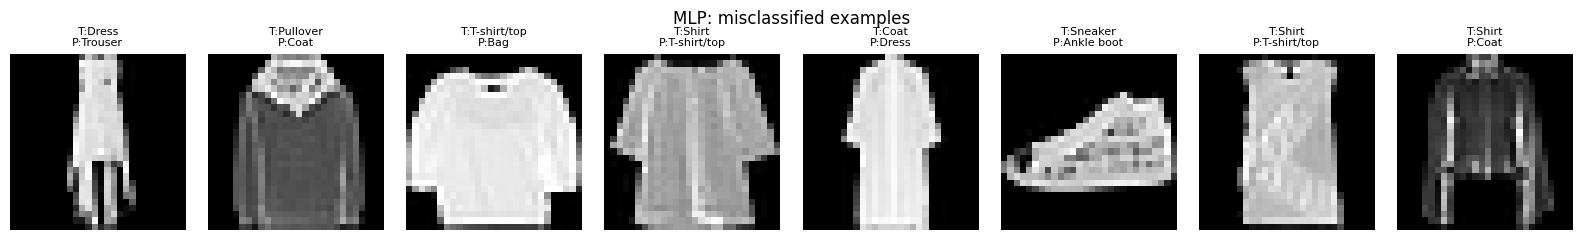

In [21]:
best_name = results_df.sort_values('test_macro_f1_mean', ascending=False).iloc[0]['model']
best_model = trained_models[best_name]["model"]
y_true = trained_models[best_name]["y_true"]
y_pred = trained_models[best_name]["y_pred"]

correct_idx = np.where(y_true == y_pred)[0]
wrong_idx = np.where(y_true != y_pred)[0]

def show_examples(indices, title, n=8, save_name=None):
    n = min(n, len(indices))
    chosen = np.random.choice(indices, size=n, replace=False) if n > 0 else []
    fig, axes = plt.subplots(1, max(n, 1), figsize=(2 * max(n, 1), 2.4))
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, chosen):
        ax.imshow(test_images[idx], cmap="gray")
        ax.set_title(f"T:{CLASS_NAMES[y_true[idx]]}\nP:{CLASS_NAMES[y_pred[idx]]}", fontsize=8)
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    if save_name:
        plt.savefig(os.path.join(FIG_DIR, save_name), dpi=150, bbox_inches="tight")
    plt.show()

show_examples(correct_idx, f"{best_name}: correctly classified examples", save_name="14_qualitative_correct.png")
show_examples(wrong_idx, f"{best_name}: misclassified examples", save_name="14_qualitative_incorrect.png")


## 15. Error analysis and inductive-bias discussion

**[TODO: discuss, after running the cells above]**

1. Which classes are confused with which, according to the confusion matrices? Do the same
   confusions appear across all five models, or only some?
2. For the misclassified examples shown above, what do they have in common (silhouette,
   texture, class ambiguity)?
3. **Inductive bias.** How does each representation change what the model can "see" first?
   - Linear/MLP: flattened pixel vector — no notion of 2-D locality.
   - CNN: local receptive fields + weight sharing — should be naturally suited to a
     spatial task like this one.
   - GRU: image treated as a *sequence of rows* — captures top-to-bottom dependency but
     breaks left-right locality within a row boundary.
   - Transformer: patches + global self-attention from the first layer — no built-in
     locality prior, relies on data and positional encoding to learn spatial structure.
   Do the results in Section 12 support these expectations? Where do they not?
4. Based on the parameter counts and training/inference times in `results_df`, which model
   gives the best accuracy-per-parameter and accuracy-per-millisecond trade-off?


## 16. Reproducibility

- The cell above (Section 0) prints the seed, Python/PyTorch/torchvision versions, device and GPU
  name actually used for this run — paste that printed block into the report instead of typing it
  by hand, so it always matches the run that produced the numbers above.
- Split: stratified, 48,000 / 12,000 / 10,000 (train/val/test — 80/20 train/val), seed 42 (Section 3).
- Checkpoint selection rule: best validation loss with early stopping (patience=3); one
  checkpoint file per architecture is written to `CKPT_DIR/<model_name>.pt` during Section 11
  (and also to Google Drive in Section 18) and can be reloaded without retraining (Section 11.1).
- Each reported number is traceable to: this notebook's commit/tag, the `MODEL_BUILDERS`
  config (Section 11), the split defined in Section 3, and the corresponding checkpoint file.
- `TODO`: paste the actual commit hash / tag of this notebook once committed to the group repo.


In [22]:
print("Reproducibility summary")
print("-" * 40)
for k, v in env_info.items():
    print(f"{k}: {v}")
print("split: stratified 48,000 / 12,000 / 10,000 (train/val/test — 80/20 train/val)")
print("checkpoint_selection_rule: best validation loss, early stopping patience=3")
print("checkpoints_dir:", os.path.abspath(CKPT_DIR))
print("checkpoint_files:", sorted(os.listdir(CKPT_DIR)))


Reproducibility summary
----------------------------------------
seed: 42
python_version: 3.13.15
torch_version: 2.11.0+cu128
torchvision_version: 0.26.0+cu128
device: cuda
gpu_name: Tesla T4
platform: Linux-6.6.122+-x86_64-with-glibc2.39
split: stratified 48,000 / 12,000 / 10,000 (train/val/test — 80/20 train/val)
checkpoint_selection_rule: best validation loss, early stopping patience=3
checkpoints_dir: /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST/checkpoints
checkpoint_files: ['CNN.pt', 'GRU.pt', 'Linear.pt', 'MLP.pt', 'Transformer.pt']


## 17. AI Usage Disclosure (assignment-level)

Fill in one entry per AI tool actually used, following the mandatory fields in Section 5.2 of
the handbook (tool + version, member, stage, purpose, affected sections, prompt summary,
how output was verified, responsible member). If no AI tool was used, replace this cell with:

> The group declares that no generative AI tool was used in this assignment.

| Tool | Used by | Task | Prompt summary | Verification | Responsible member |
|------|---------|------|-----------------|---------------|---------------------|
| TODO | TODO    | TODO | TODO            | TODO          | TODO                |


## 18. Save results to Google Drive

Persists everything needed to write up the report or resume analysis later, without re-training:
the results table, every model's training history, and every trained model's weights.

In [23]:
import pickle

# 1) Results table (accuracy, macro-F1, params, timings per model)
results_csv_path = os.path.join(RESULTS_DIR, "a1_results_summary.csv")
results_df.to_csv(results_csv_path, index=False)

# 2) Training / validation histories for every model
histories_path = os.path.join(RESULTS_DIR, "a1_histories.pkl")
with open(histories_path, "wb") as f:
    pickle.dump(histories, f)

# 3) Trained model weights (state_dict only, one file per model)
for name, d in trained_models.items():
    ckpt_path = os.path.join(CKPT_DIR, f"{name}.pt")
    torch.save(d["model"].state_dict(), ckpt_path)

# 4) Raw predictions (y_true / y_pred) for later error analysis, without re-running inference
preds_path = os.path.join(RESULTS_DIR, "a1_test_predictions.pkl")
with open(preds_path, "wb") as f:
    pickle.dump({name: {"y_true": d["y_true"], "y_pred": d["y_pred"]} for name, d in trained_models.items()}, f)

print("Saved:")
print(" -", results_csv_path)
print(" -", histories_path)
print(" -", preds_path)
print(" -", CKPT_DIR, f"({len(trained_models)} model checkpoints)")
print(" -", FIG_DIR, "(figures)")

Saved:
 - /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST/results/a1_results_summary.csv
 - /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST/results/a1_histories.pkl
 - /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST/results/a1_test_predictions.pkl
 - /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST/checkpoints (3 model checkpoints)
 - /content/drive/MyDrive/CO3133_Assignments/A1_Foundations_FashionMNIST/figures (figures)
